In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('CarPricesData.csv')
df.head()

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986,Diesel,90,1,0,2000.0,3,1165.0
1,13750,23.0,72937,Diesel,90,1,0,2000.0,3,1165.0
2,13950,24.0,41711,Diesel,90,1,0,2000.0,3,1165.0
3,14950,26.0,48000,Diesel,90,0,0,2000.0,3,1165.0
4,13750,30.0,38500,Diesel,90,0,0,2000.0,3,1170.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1436 non-null   int64  
 1   Age        1434 non-null   float64
 2   KM         1436 non-null   int64  
 3   FuelType   1432 non-null   object 
 4   HP         1436 non-null   int64  
 5   MetColor   1436 non-null   int64  
 6   Automatic  1436 non-null   int64  
 7   CC         1434 non-null   float64
 8   Doors      1436 non-null   int64  
 9   Weight     1434 non-null   float64
dtypes: float64(3), int64(6), object(1)
memory usage: 112.3+ KB


In [4]:
print(df.isnull().sum())

Price        0
Age          2
KM           0
FuelType     4
HP           0
MetColor     0
Automatic    0
CC           2
Doors        0
Weight       2
dtype: int64


In [5]:
df.nunique()

Price         236
Age            77
KM           1263
FuelType        3
HP             12
MetColor        2
Automatic       2
CC             12
Doors           4
Weight         59
dtype: int64

In [6]:
df.describe()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight
count,1436.000000,1434.000000,1436.000000,1436.000000,1436.000000,1436.000000,1434.000000,1436.000000,1434.000000
mean,10730.824513,55.986750,68533.259749,101.502089,0.674791,0.055710,1566.990934,4.033426,1072.487448
std,3626.964585,18.581796,37506.448872,14.981080,0.468616,0.229441,187.178221,0.952677,52.672475
min,4350.000000,1.000000,1.000000,69.000000,0.000000,0.000000,1300.000000,2.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,0.000000,1400.000000,3.000000,1040.000000
50%,9900.000000,61.000000,63389.500000,110.000000,1.000000,0.000000,1600.000000,4.000000,1070.000000
75%,11950.000000,70.000000,87020.750000,110.000000,1.000000,0.000000,1600.000000,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,1.000000,2000.000000,5.000000,1615.000000


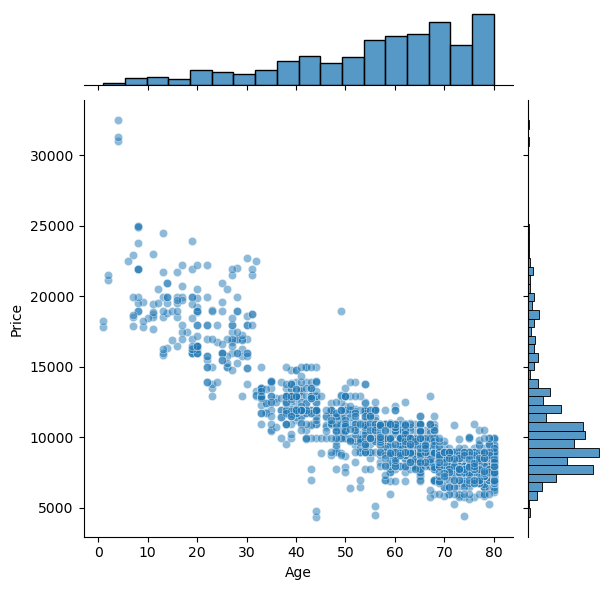

In [7]:
sns.jointplot(x='Age', y= 'Price', data = df , alpha = 0.5)

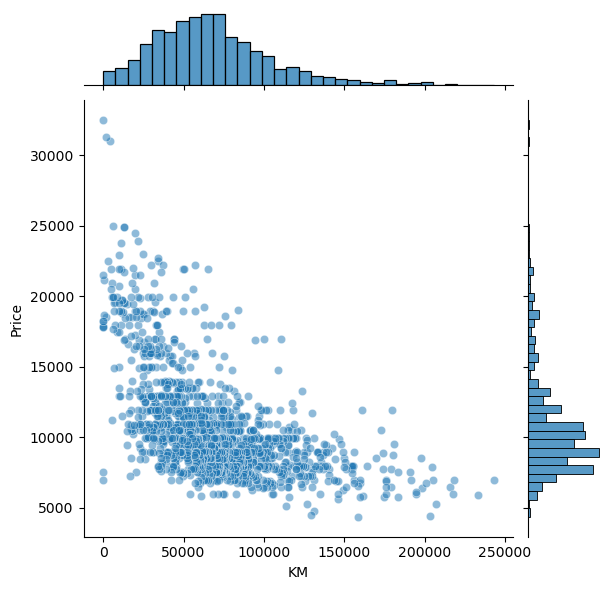

In [8]:
sns.jointplot(x='KM', y= 'Price', data = df, alpha = 0.5)

In [9]:
df['Age'].fillna(df['Age'].median(), inplace = True)
df['CC'].fillna(df['CC'].median(), inplace = True)
df['Weight'].fillna(df['Weight'].median(), inplace = True)
df['FuelType'].fillna(df['FuelType'].mode(), inplace = True)

df_encoded = pd.get_dummies(df , columns = ['FuelType'], drop_first = True)
df_encoded.head()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight,FuelType_Diesel,FuelType_Petrol
0,13500,23.0,46986,90,1,0,2000.0,3,1165.0,True,False
1,13750,23.0,72937,90,1,0,2000.0,3,1165.0,True,False
2,13950,24.0,41711,90,1,0,2000.0,3,1165.0,True,False
3,14950,26.0,48000,90,0,0,2000.0,3,1165.0,True,False
4,13750,30.0,38500,90,0,0,2000.0,3,1170.0,True,False


<__array_function__ internals>:200: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
<__array_function__ internals>:200: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
C:\Users\kanis\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


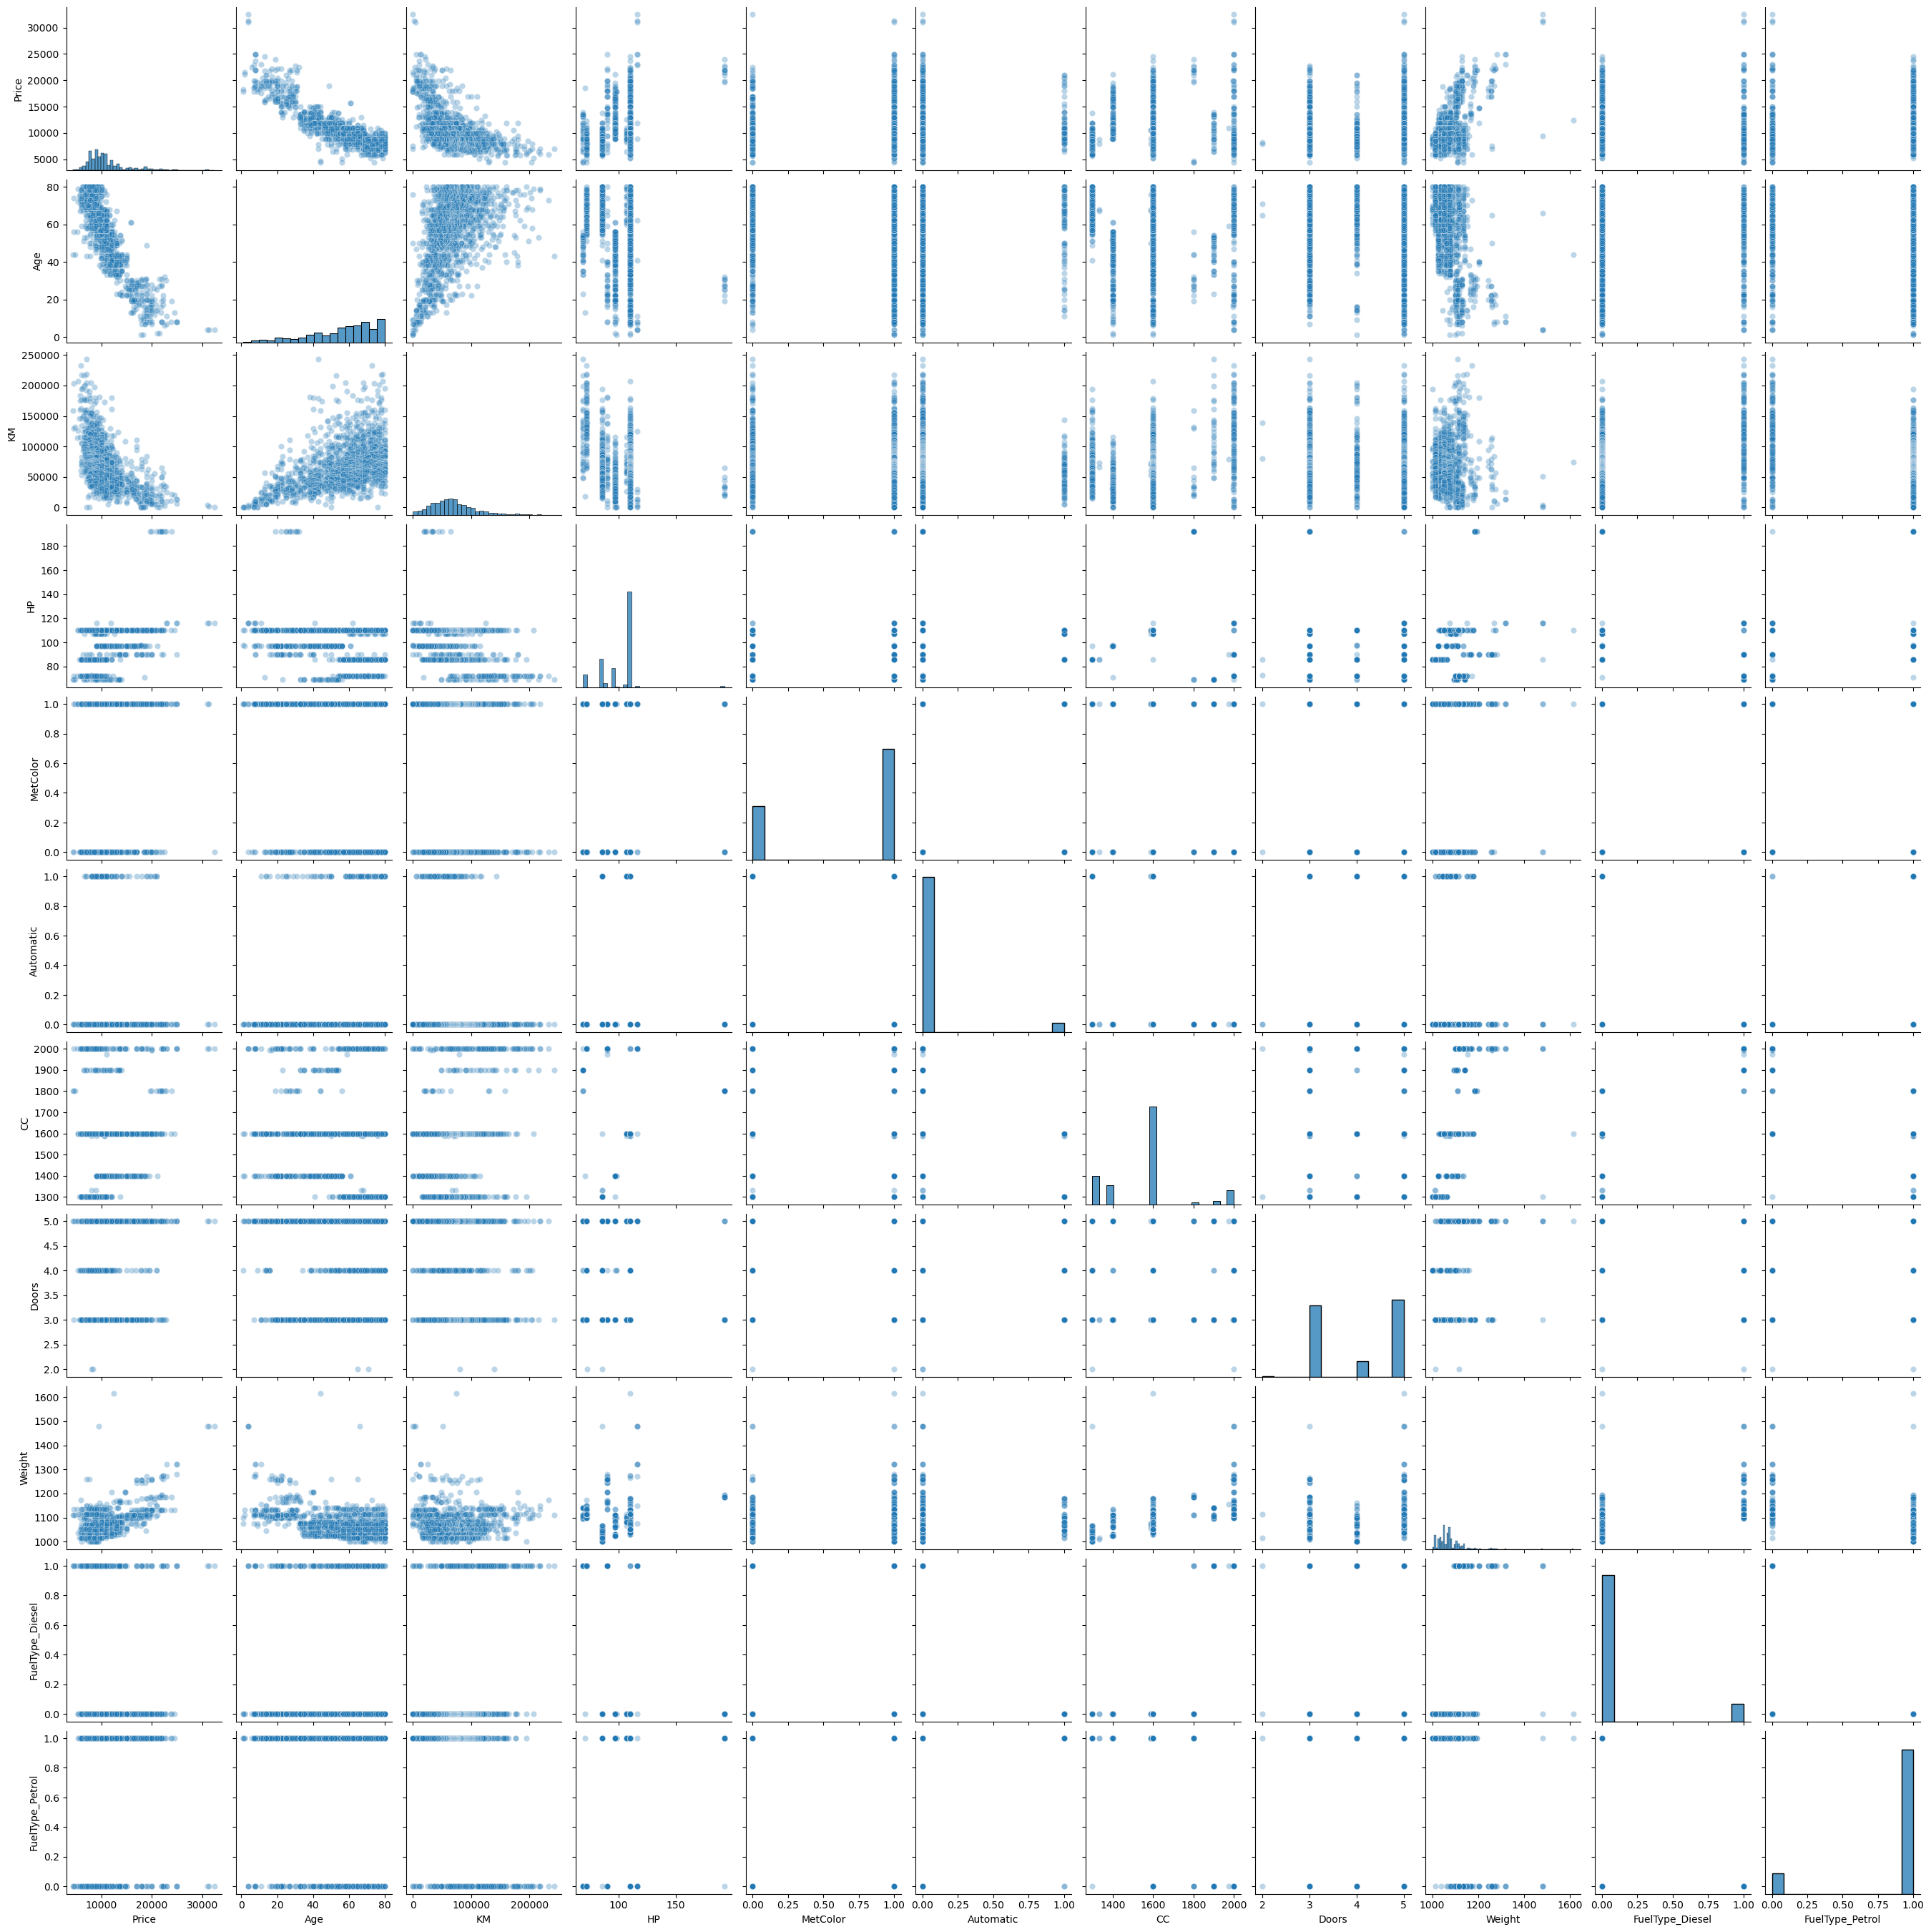

In [10]:
sns.pairplot(df_encoded, kind = 'scatter', plot_kws = {'alpha' : 0.3})

In [34]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

from sklearn.linear_model import LinearRegression 
lm1 = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.api as sm2
import warnings

In [39]:
lm1=smf.ols(formula='Price ~ Age+KM+HP+MetColor+FuelType_Diesel+FuelType_Petrol+CC+Doors+Weight+Automatic', data=df_encoded).fit()
lm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     931.2
Date:                Sat, 11 Jan 2025   Prob (F-statistic):               0.00
Time:                        19:33:40   Log-Likelihood:                -12357.
No. Observations:                1436   AIC:                         2.474e+04
Df Residuals:                    1425   BIC:                         2.479e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -3661.9496   1286.481     -2.846      0.004   -6185.550   -1138.350
FuelType_Diesel[T.True]  3159.8969    516.412      6.119      0.000    2146.888    4172.906
FuelType_Petrol[T.True]   838.8049    300.114      2.795      0.005     250.092    1427.518
Age                      -121.0508      2.616    -46.273      0.000    -126.182    -115.919
KM                         -0.0167      0.001    -12.733      0.000      -0.019      -0.014
HP                         61.0152      5.771     10.573      0.000      49.695      72.335
MetColor                   66.9941     75.527      0.887      0.375     -81.163     215.151
CC                         -4.2674      0.547     -7.801      0.000      -5.340      -3.194
Doors                      -7.9961     40.384     -0.198      0.843     -87.214      71.222
Weight                     20.2378      1.206     16.777      0.000      17.871      22.604
Automatic                 320.4451    158.250      2.025      0.043      10.017     630.873
==============================================================================
Omnibus:                      273.434   Durbin-Watson:                   1.604
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2859.236
Skew:                          -0.562   Prob(JB):                         0.00
Kurtosis:                       9.821   Cond. No.                     2.90e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.9e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [60]:
lm1=smf.ols(formula='Price ~ Age+KM+HP+FuelType_Diesel+FuelType_Petrol+CC+Weight', data=df_encoded).fit()
lm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     1328.
Date:                Sat, 11 Jan 2025   Prob (F-statistic):               0.00
Time:                        19:51:22   Log-Likelihood:                -12359.
No. Observations:                1436   AIC:                         2.473e+04
Df Residuals:                    1428   BIC:                         2.478e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -4011.2270   1226.756     -3.270      0.001   -6417.664   -1604.790
FuelType_Diesel[T.True]  3022.5217    502.627      6.013      0.000    2036.556    4008.487
FuelType_Petrol[T.True]   816.8809    299.771      2.725      0.007     228.843    1404.919
Age                      -120.5152      2.593    -46.483      0.000    -125.601    -115.429
KM                         -0.0170      0.001    -12.996      0.000      -0.020      -0.014
HP                         59.5735      5.613     10.614      0.000      48.564      70.584
CC                         -4.1933      0.538     -7.791      0.000      -5.249      -3.138
Weight                     20.6410      1.106     18.658      0.000      18.471      22.811
==============================================================================
Omnibus:                      289.976   Durbin-Watson:                   1.609
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3126.052
Skew:                          -0.610   Prob(JB):                         0.00
Kurtosis:                      10.124   Cond. No.                     2.76e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.76e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: ylabel='Price'>

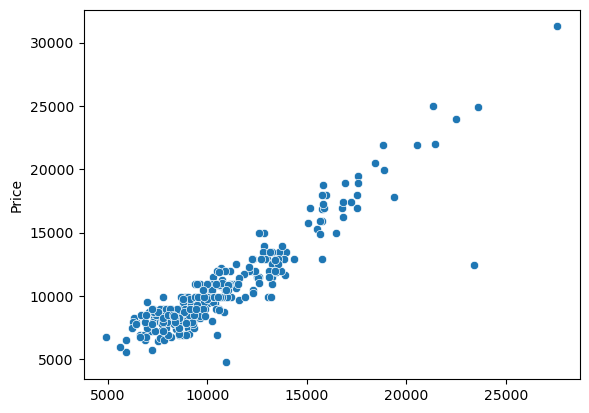

In [61]:
predictions = lm1.predict(X_test)
sns.scatterplot(x=predictions, y=y_test)

In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
print('Mean Absolute_Error : ' , mean_absolute_error(y_test, predictions))
print('Mean Squared Error : ' , mean_squared_error(y_test, predictions))
print('RMSE : ' , math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute_Error :  948.6993017559156
Mean Squared Error :  1862819.440296405
RMSE :  1364.8514352472232


C:\Users\kanis\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kanis\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


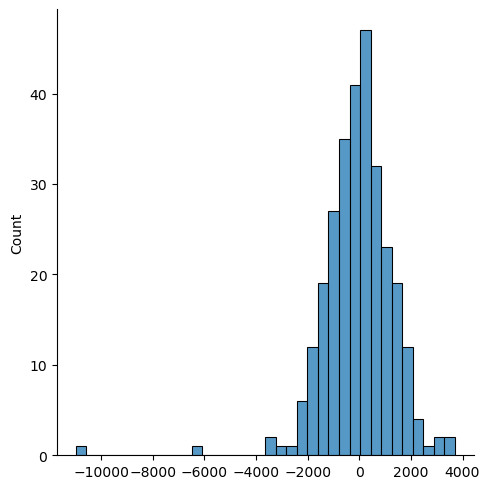

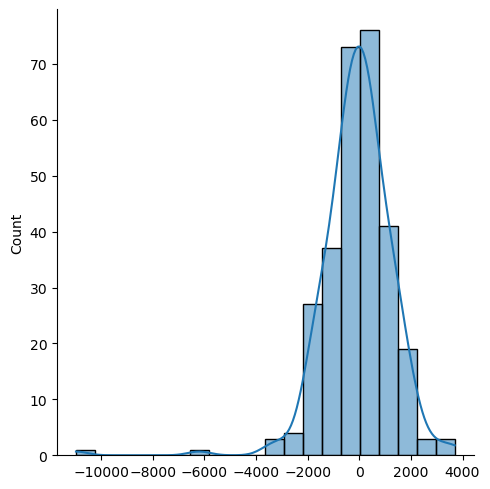

In [64]:
Residuals = y_test - predictions
sns.displot(Residuals )
sns.displot(Residuals , bins = 20 , kde = True)

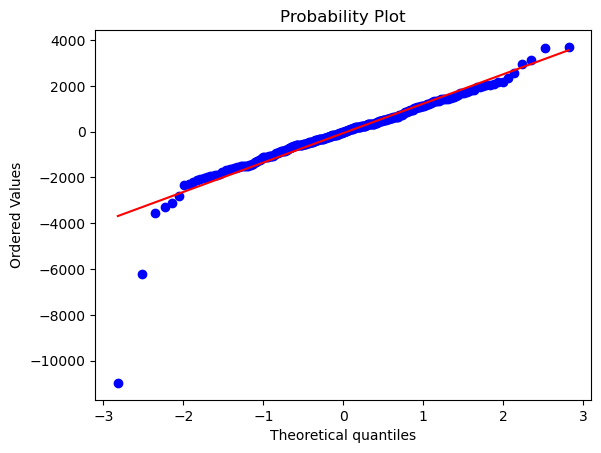

In [65]:
import pylab
import scipy.stats as stats

stats.probplot(Residuals , dist = "norm" , plot = pylab)
pylab.show()